## CRS Transformations & Distance Calculations

**Data:** CAL FIRE historical fire perimeters (`fire24_1.gdb`, 2010–2025)

**What this notebook does:**
- Reprojects fire perimeters from **EPSG:3310** (California Albers, meters) to **EPSG:4326** (WGS84, lat/lon) to illustrate the difference between projected and geographic coordinate systems
- Computes the centroid of each fire polygon and measures its distance to 5 major CA cities: Los Angeles, San Francisco, Sacramento, San Diego, and Fresno
- Identifies the 5 fires that burned closest to Los Angeles — led by **Griffith Park (2015)** at ~10.7 km
- Filters and maps all 832 fires that occurred within 100 km of Los Angeles (2010–2025)

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

## Reprojections
 Loading the GDF and transforming from EPSG 3310 to 4326 has significance. EPSG 3310 will represent a projected CRS in meters. This can be used for distance calculations utilizing a reference point in California. EPSG 4326 is a geographic CRS. This will display in Lat/Long. This can be used for API calls.

In [11]:
# Load fire perimeters and project from EPSG 3310 California Albers to EPSG 4326 WGS 84
gdf = gpd.read_file("../data/raw/fire24_1.gdb", layer="firep24_1")
gdf_recent = gdf[gdf['YEAR_'] >= 2010]
print(gdf.crs)
print(gdf.geometry.iloc[0].centroid)
gdf_latlon = gdf_recent.to_crs(epsg=4326)
print(gdf_latlon.crs)
print(gdf_latlon.geometry.iloc[0].centroid)

EPSG:3310
POINT (131594.50970948034 -437120.20474058104)
EPSG:4326
POINT (-118.57420527184718 34.07263128269732)


## Calculating Fire Centroid Distances to Major California Cities

In [ ]:
# Create variable for centroids of fire perimeters
centers = gdf_recent.centroid
print(centers)

0        POINT (131594.51 -437120.205)
1       POINT (175755.502 -422125.449)
2       POINT (129867.003 -385044.139)
3       POINT (121277.591 -425898.009)
4       POINT (139844.002 -408130.445)
                     ...              
5456    POINT (-223118.209 412308.877)
5457    POINT (-232536.303 401745.375)
5458    POINT (128186.612 -429343.763)
5459    POINT (-225752.308 435219.523)
5460    POINT (-243582.691 384331.449)
Length: 5461, dtype: geometry


In [21]:
# Create City dictionary with city names as keys and (longitude, latitude) tuples as values. Then create a GeoDataFrame from the dictionary and set the CRS to EPSG 4326 WGS 84.
cities = {
    'city': ['Los Angeles', 'San Francisco', 'Sacramento', 'San Diego', 'Fresno'],
    'geometry': [Point(-118.2437, 34.0522), Point(-122.4194, 37.7749), Point(-121.4944, 38.5816), Point(-117.1611, 32.7157), Point(-119.7871, 36.7378)]
}
cities_gdf = gpd.GeoDataFrame(cities, geometry='geometry', crs='EPSG:4326')
cities_3310 = cities_gdf.to_crs(epsg=3310)
print(cities_3310)

            city                        geometry
0    Los Angeles  POINT (162138.862 -438874.829)
1  San Francisco  POINT (-212792.008 -24127.707)
2     Sacramento   POINT (-130031.426 63858.194)
3      San Diego  POINT (266493.679 -584522.763)
4         Fresno    POINT (18985.957 -142104.54)


In [35]:
# Distance calculations by city divided by 1000 to convert from meters to kilometers
LA = cities_3310[cities_3310['city'] == 'Los Angeles'].geometry.iloc[0]
distance_to_la = centers.distance(LA) / 1000
print(distance_to_la)

# Complete for four remaining cities
SF = cities_3310[cities_3310['city'] == 'San Francisco'].geometry.iloc[0]
distance_to_sf = centers.distance(SF) / 1000
SD = cities_3310[cities_3310['city'] == 'San Diego'].geometry.iloc[0]
distance_to_sd = centers.distance(SD) / 1000
SAC = cities_3310[cities_3310['city'] == 'Sacramento'].geometry.iloc[0]
distance_to_sac = centers.distance(SAC) / 1000
FRE = cities_3310[cities_3310['city'] == 'Fresno'].geometry.iloc[0]
distance_to_fre = centers.distance(FRE) / 1000

0        30.594708
1        21.585981
2        62.763174
3        42.872384
4        37.977335
           ...    
5456    934.310822
5457    928.660763
5458     35.264663
5459    956.295193
5460    917.757350
Length: 5461, dtype: float64


In [ ]:
# Adding distance columns in original GeoDataFrame
gdf_recent['distance_to_LA_km'] = distance_to_la
gdf_recent['distance_to_SF_km'] = distance_to_sf
gdf_recent['distance_to_SD_km'] = distance_to_sd
gdf_recent['distance_to_SAC_km'] = distance_to_sac
gdf_recent['distance_to_FRE_km'] = distance_to_fre
gdf_recent.head()

,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,C_METHOD,...,COMMENTS,FIRE_NUM,Shape_Length,Shape_Area,geometry,distance_to_LA_km,distance_to_SF_km,distance_to_SD_km,distance_to_SAC_km,distance_to_FRE_km
0,2025.0,CA,CDF,LDF,PALISADES,00000738,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},2025-01-07 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,...,NaN,NaN,116028.197349,9.489426e+07,"MULTIPOLYGON (((136696.228 -441776.379, 136683...",30.594708,537.740529,199.813163,565.179163,315.776707
1,2025.0,CA,CDF,LAC,EATON,00009087,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},2025-01-08 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,...,NaN,NaN,86677.545056,5.688367e+07,"MULTIPOLYGON (((175062.878 -425909.927, 175066...",21.585981,556.211623,186.027698,574.182678,320.918058
2,2025.0,CA,CDF,ANF,HUGHES,00250270,{994072D2-E154-434A-BB95-6F6C94C40829},2025-01-22 00:00:00+00:00,2025-01-28 00:00:00+00:00,7.0,...,NaN,NaN,79554.126153,4.207435e+07,"MULTIPOLYGON (((132177.534 -380697.661, 132181...",62.763174,497.670442,241.782071,518.710419,267.047290
3,2025.0,CA,CCO,VNC,KENNETH,00003155,{842FB37B-7AC8-4700-BB9C-028BF753D149},2025-01-09 00:00:00+00:00,2025-02-04 00:00:00+00:00,2.0,...,from OES Intel 24,NaN,12891.056545,4.041748e+06,"MULTIPOLYGON (((121967.885 -426575.817, 121970...",42.872384,522.514950,215.057027,550.470127,301.665894
4,2025.0,CA,CDF,LDF,HURST,00003294,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},2025-01-07 00:00:00+00:00,2025-01-09 00:00:00+00:00,7.0,...,NaN,NaN,13274.108148,3.364498e+06,"MULTIPOLYGON (((140774.966 -408332.494, 140784...",37.977335,521.354254,217.150618,543.696627,292.192486


In [42]:
# Example analysis: finding the top 5 closest fires to Los Angeles
gdf_recent.nsmallest(5, 'distance_to_LA_km')[['FIRE_NAME', 'YEAR_', 'distance_to_LA_km']]

,FIRE_NAME,YEAR_,distance_to_LA_km
3998,GRIFFITH PARK,2015.0,10.681268
2159,BARHAM,2019.0,13.124894
2346,HOLLYWOOD HILLS,2019.0,14.619723
3821,LINCOLN,2015.0,15.986393
1104,SYCAMORE,2022.0,19.498594


## Plotting All Fires Within 100km of Los Angeles

In [48]:
LA_100_km = gdf_recent[gdf_recent['distance_to_LA_km'] <= 100]
print(len(LA_100_km))


832


(np.float64(-13288238.78822992),
 np.float64(-13030111.750334913),
 np.float64(3934061.087091555),
 np.float64(4168871.1217766525))

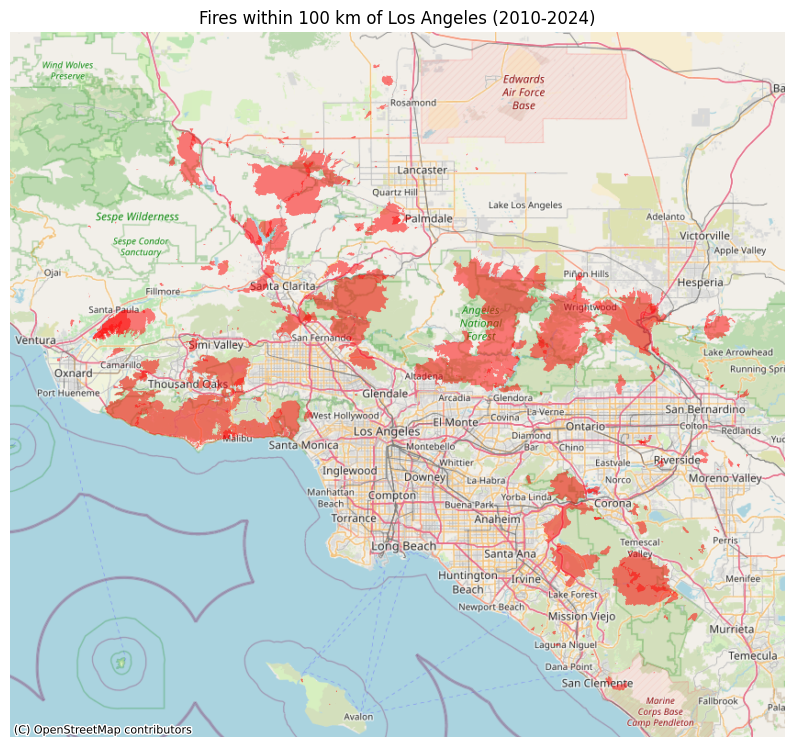

In [58]:
LA_3857 = LA_100_km.to_crs(epsg=3857)
fig, ax=plt.subplots(figsize=(10, 10))
LA_3857.plot(ax=ax, color='red', alpha=0.5)
ctx.add_basemap(ax,source=ctx.providers.OpenStreetMap.Mapnik)
plt.title('Fires within 100 km of Los Angeles (2010-2024)')
plt.axis('off')